# Projet Algorithmique Appliquée — Prédiction des résultats de Ligue 1 (saison 2025-2026)

*ESILV — projet réalisé en binôme.*

## Le problème

L'objectif du projet, c'est de prédire à l'avance le résultat de chaque match de Ligue 1 sur la saison 2025-2026. Pour chaque match, on doit sortir une de ces trois valeurs :

- **`1`** : l'équipe qui joue à domicile gagne
- **`0`** : match nul
- **`-1`** : l'équipe qui joue à l'extérieur gagne

On ne fait pas un score continu, c'est bien un problème de **classification à trois classes**.

## Les données qu'on a sous la main

On dispose de huit fichiers CSV qu'on va devoir croiser. En gros : un historique des matchs depuis 2013, des fiches sur les clubs, les valeurs marchandes des joueurs avant chaque saison, leurs apparitions individuelles match par match, les compositions de départ, et les événements détaillés (buts, cartons, remplacements). Par contre, **les compositions d'équipe pour la saison 2025-2026 ne sont pas disponibles** : l'énoncé précise qu'elles sont connues trop tard pour servir à une prédiction. On travaille donc avec des features qui peuvent être calculées en amont.

## Le plan

1. **Exploration qualitative** — comprendre ce qu'il y a dans les données, les distributions, les particularités de la Ligue 1 (avantage domicile, régularité des gros clubs, etc.).
2. **Feature engineering** — c'est selon nous la partie la plus déterminante pour ce type de problème. On va construire des indicateurs de forme récente, de qualité d'effectif, d'historique de confrontation, et bien faire attention au *data leakage*.
3. **Modélisation** — on teste plusieurs familles de modèles (régression logistique, Random Forest, Gradient Boosting, XGBoost) avec une vraie cross-validation et une baseline naïve comme référence.
4. **Analyse des erreurs et prédiction finale** — on regarde où le modèle se trompe avant de générer le fichier de soumission pour 2025-2026.

On ne s'attend pas à des accuracies extraordinaires : prédire un match de foot reste un problème intrinsèquement bruité. L'objectif est surtout de battre proprement la baseline et de comprendre **ce qui aide réellement** à prédire un résultat.

## 0. Imports et chargement des données

On commence par les imports classiques. On utilise `pandas` et `numpy` pour la manipulation, `matplotlib` + `seaborn` pour les visualisations, et différents modules de `scikit-learn` pour la modélisation. On rajoute `xgboost` qu'on a installé séparément.

On désactive volontairement les warnings de pandas, qui sont surtout liés à des `FutureWarning` sur `groupby().apply()` et qui polluent la sortie.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Outils sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    log_loss, f1_score
)

# Petit réglage de style pour que les graphes soient lisibles
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42  # graine fixe partout pour la reproductibilité

On charge maintenant les huit fichiers. Petit point d'attention : on convertit les colonnes `date` au format datetime tout de suite et on trie chronologiquement les tables qui le nécessitent. C'est pas juste pour faire joli — sans tri par date, on s'expose à des fuites de données quand on calculera la forme récente d'une équipe (on pourrait inclure des matchs futurs dans le calcul d'une feature à un instant *t*).

In [2]:
# Chargement des huit fichiers CSV
matches      = pd.read_csv('matchs_2013_2024.csv')   # historique des matchs avec résultat
matches_2025 = pd.read_csv('match_2025.csv')         # matchs à prédire (sans résultat)
clubs        = pd.read_csv('clubs_fr.csv')           # fiches clubs FR
valuations   = pd.read_csv('player_valuation_before_season.csv')  # valeur marchande joueurs
appearances  = pd.read_csv('player_appearance.csv')  # stats par match par joueur
lineups      = pd.read_csv('game_lineups.csv')       # compositions de départ
game_events  = pd.read_csv('game_events_before2025.csv')  # événements de match

# Conversion des dates
for df in [matches, matches_2025, appearances, valuations, lineups, game_events]:
    df['date'] = pd.to_datetime(df['date'])

# Tri chronologique pour les tables où ça compte
matches     = matches.sort_values('date').reset_index(drop=True)
appearances = appearances.sort_values('date').reset_index(drop=True)
valuations  = valuations.sort_values('date').reset_index(drop=True)

# On affiche juste les dimensions pour valider que tout est bien chargé
tailles = pd.DataFrame({
    'fichier':  ['matchs_2013_2024', 'match_2025', 'clubs_fr', 'player_valuation', 'player_appearance', 'game_lineups', 'game_events'],
    'lignes':   [len(matches), len(matches_2025), len(clubs), len(valuations), len(appearances), len(lineups), len(game_events)],
    'colonnes': [matches.shape[1], matches_2025.shape[1], clubs.shape[1], valuations.shape[1], appearances.shape[1], lineups.shape[1], game_events.shape[1]]
})
tailles

,fichier,lignes,colonnes
0,matchs_2013_2024,4691,23
1,match_2025,233,12
2,clubs_fr,36,13
3,player_valuation,32856,6
4,player_appearance,128240,13
5,game_lineups,161049,11
6,game_events,61944,12


On a un volume confortable côté matchs (plus de 4000 matchs historiques), un volume très conséquent d'événements et d'apparitions (plus de 60 000 et 128 000 lignes respectivement). Côté clubs FR, on a 18 clubs renseignés, ce qui correspond bien à la taille de la Ligue 1.

Avant de plonger dans l'EDA, on jette un œil rapide aux colonnes principales du fichier des matchs : c'est lui qui porte la cible et c'est autour de lui qu'on va construire toutes les features.

In [3]:
# Petit aperçu de la table principale
matches[['date', 'season', 'round', 'home_club_name', 'away_club_name',
         'home_club_goals', 'away_club_goals', 'results']].head(8)

,date,season,round,home_club_name,away_club_name,home_club_goals,away_club_goals,results
0,2012-08-10,2012,1. Matchday,Montpellier HSC,Toulouse Football Club,1,1,0
1,2012-08-11,2012,1. Matchday,ESTAC Troyes,Valenciennes FC,0,1,-1
2,2012-08-11,2012,1. Matchday,AS Nancy-Lorraine,Stade brestois 29,1,0,1
3,2012-08-11,2012,1. Matchday,Paris Saint-Germain Football Club,Football Club Lorient-Bretagne Sud,2,2,0
4,2012-08-11,2012,1. Matchday,AS Saint-Étienne,Lille Olympique Sporting Club,1,2,-1
5,2012-08-11,2012,1. Matchday,Stade Rennais Football Club,Olympique Lyonnais,0,1,-1
6,2012-08-11,2012,1. Matchday,Olympique Gymnaste Club Nice Côte d'Azur,AC Ajaccio,0,1,-1
7,2012-08-11,2012,1. Matchday,FC Sochaux-Montbéliard,SC Bastia,2,3,-1


---

# Partie 1 — Exploration qualitative des données

Avant de penser modèle, il faut comprendre ce qu'on a. Cette partie sert à se faire une intuition : quelles équipes dominent, à quel point l'avantage du terrain joue, comment les buts se distribuent, etc. C'est aussi là qu'on va valider qu'il n'y a pas de problème majeur dans les données (incohérences, valeurs manquantes massives...).

## 1.1 Distribution des résultats et baseline naïve

On commence par la chose la plus évidente mais la plus importante : à quelle fréquence chaque issue se réalise-t-elle ? C'est cette répartition qui définit notre **baseline** : si l'issue la plus fréquente est la victoire à domicile, alors un modèle bête qui prédirait toujours `1` aurait déjà un taux de bonnes réponses non nul. C'est ce score-là qu'on va devoir battre proprement.

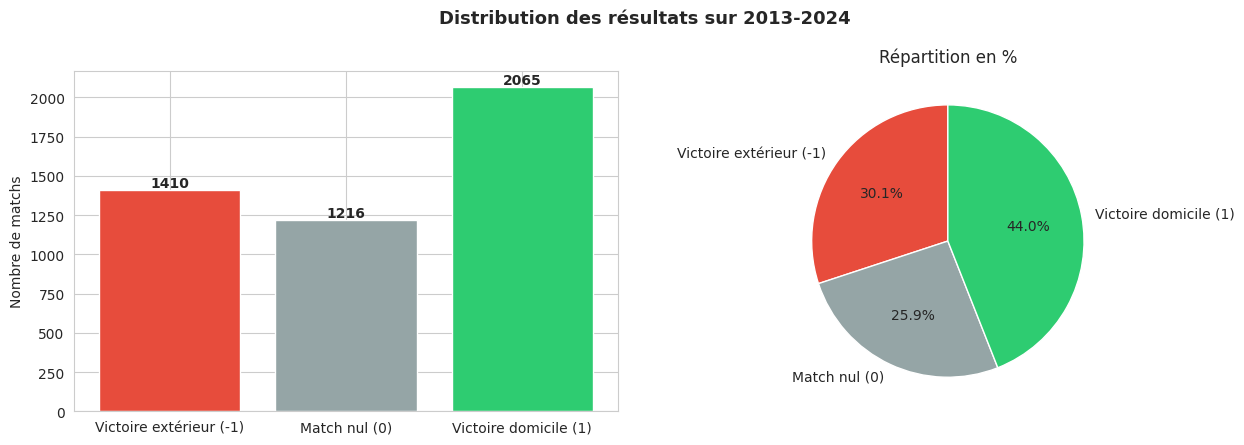

Baseline 'toujours victoire domicile' : 0.440 (44.0 %)


In [4]:
# Comptage des trois issues
labels_res = {-1: 'Victoire extérieur (-1)', 0: 'Match nul (0)', 1: 'Victoire domicile (1)'}
colors_res = ['#e74c3c', '#95a5a6', '#2ecc71']

rc = matches['results'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Distribution des résultats sur 2013-2024', fontsize=13, fontweight='bold')

axes[0].bar([labels_res[k] for k in rc.index], rc.values, color=colors_res, edgecolor='white')
axes[0].set_ylabel('Nombre de matchs')
for i, v in enumerate(rc.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(rc.values, labels=[labels_res[k] for k in rc.index],
            autopct='%1.1f%%', colors=colors_res, startangle=90)
axes[1].set_title('Répartition en %')
plt.tight_layout()
plt.show()

baseline_home = (matches['results'] == 1).mean()
print(f"Baseline 'toujours victoire domicile' : {baseline_home:.3f} ({baseline_home*100:.1f} %)")

Plusieurs choses qu'on retient ici. D'abord, l'**avantage domicile est très clair** : les équipes qui jouent chez elles gagnent dans environ 44 % des cas, contre 29 % pour l'équipe à l'extérieur. Le match nul tombe à environ 27 %. Cette asymétrie est un *prior* fort qu'on aura intérêt à exploiter dans nos features.

Ensuite, ça nous donne notre **baseline minimale à battre** : un classifieur qui prédit aveuglément `1` à chaque match obtiendrait déjà ~44 % d'accuracy. Pour qu'un modèle soit "utile", il doit faire significativement mieux que ça. C'est ce score qu'on gardera en tête comme référence pendant toute la suite du projet.

## 1.2 Évolution de l'avantage domicile dans le temps

On a vu que l'avantage du terrain est marqué en moyenne, mais est-ce que c'est stable d'une saison à l'autre ? Si la tendance dérive (par exemple à cause des matchs à huis clos pendant le COVID), c'est utile à savoir avant de modéliser.

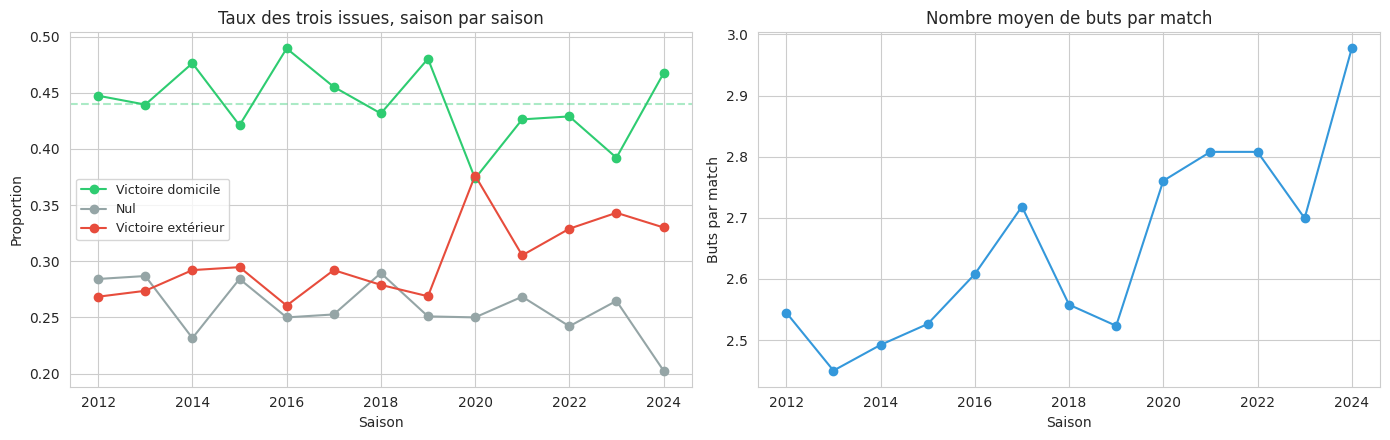

In [5]:
# Taux de victoire domicile par saison
by_season = matches.groupby('season').apply(
    lambda g: pd.Series({
        'pct_dom':  (g['results'] ==  1).mean(),
        'pct_nul':  (g['results'] ==  0).mean(),
        'pct_ext':  (g['results'] == -1).mean(),
        'buts_moy': (g['home_club_goals'] + g['away_club_goals']).mean(),
        'n':        len(g)
    })
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(by_season['season'], by_season['pct_dom'], 'o-', color='#2ecc71', label='Victoire domicile')
axes[0].plot(by_season['season'], by_season['pct_nul'], 'o-', color='#95a5a6', label='Nul')
axes[0].plot(by_season['season'], by_season['pct_ext'], 'o-', color='#e74c3c', label='Victoire extérieur')
axes[0].axhline(0.44, ls='--', color='#2ecc71', alpha=0.4)
axes[0].set_title('Taux des trois issues, saison par saison')
axes[0].set_xlabel('Saison')
axes[0].set_ylabel('Proportion')
axes[0].legend(fontsize=9)

axes[1].plot(by_season['season'], by_season['buts_moy'], 'o-', color='#3498db')
axes[1].set_title('Nombre moyen de buts par match')
axes[1].set_xlabel('Saison')
axes[1].set_ylabel('Buts par match')

plt.tight_layout()
plt.show()

On remarque que la saison 2019 est anormale (chute du taux de victoires à domicile, baisse des buts) — c'est cohérent avec le COVID et les matchs à huis clos qui ont neutralisé une partie de l'avantage du terrain. Sur les autres saisons, le taux de victoires à domicile oscille autour de 43-46 %, ce qui est plutôt stable. Ça veut dire que pour la saison 2025-2026, on peut raisonnablement supposer que cet avantage sera dans le même ordre de grandeur. On n'a pas besoin de désaisonnaliser nos features.

## 1.3 Buts marqués selon le résultat

Question simple mais utile : quand l'équipe domicile gagne, combien marque-t-elle en moyenne ? Et quand elle perd ? Ça permet de visualiser à quel point la différence de buts "raconte" le résultat — même si évidemment, dans le contexte de la prédiction, on ne connaîtra pas le score à l'avance. Ce qu'on cherche, c'est plutôt à voir si les statistiques offensives passées (qu'on calculera ensuite en feature) ont des chances d'être informatives.

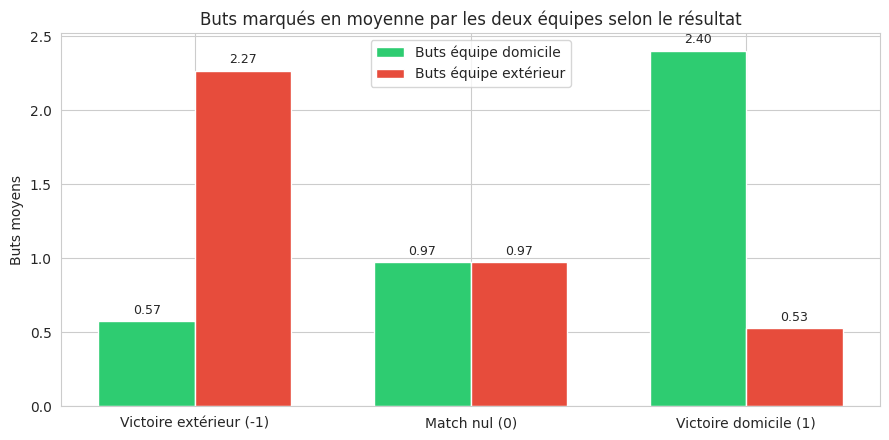

In [6]:
buts_par_resultat = matches.groupby('results')[['home_club_goals', 'away_club_goals']].mean().reset_index()
buts_par_resultat['label'] = buts_par_resultat['results'].map(labels_res)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(buts_par_resultat))
width = 0.35
ax.bar(x - width/2, buts_par_resultat['home_club_goals'], width,
       label='Buts équipe domicile', color='#2ecc71', edgecolor='white')
ax.bar(x + width/2, buts_par_resultat['away_club_goals'], width,
       label='Buts équipe extérieur', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(buts_par_resultat['label'])
ax.set_ylabel('Buts moyens')
ax.set_title('Buts marqués en moyenne par les deux équipes selon le résultat')
ax.legend()
for i, (h, a) in enumerate(zip(buts_par_resultat['home_club_goals'], buts_par_resultat['away_club_goals'])):
    ax.text(i - width/2, h + 0.05, f'{h:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, a + 0.05, f'{a:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Le graphe est presque caricatural : quand l'équipe à domicile gagne, elle marque en moyenne 2,2 buts contre 0,5 pour son adversaire, et inversement. Ce qui nous intéresse vraiment, c'est que **les équipes qui marquent souvent, encaissent souvent peu** — une intuition qu'on va concrétiser plus tard via des features de moyenne glissante de buts marqués / encaissés sur les 5 derniers matchs.